In [1]:
import os
import re
import glob
from IPython.display import display
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
#import japanize_matplotlib
import seaborn as sns 
import unicodedata
import yaml



In [2]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [3]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

# データ読み込み

In [15]:
dict_dtype_station = {
    "station_id": "int64",
    "lat": "float64",
    "long": "float64",
    "dock_count": "int64",
    "city": "object",
    "installation_date": "object",
}
dict_dtype_status = {
    "id": "int64",
    "year": "int64",
    "month": "int64",
    "day": "int64",
    "hour": "int64",
    "station_id": "int64",
    "bikes_available": "float64",
    "predict": "int64",
}
dict_dtype_trip = {
    "trip_id": "int64",
    "duration": "int64",
    "start_date": "object",
    "start_station_id": "int64",
    "end_date": "object",
    "end_station_id": "int64",
    "bike_id": "int64",
    "subscription_type": "object",
}
dict_dtype_weather = {
    "date": "object",
    "max_temperature": "int64",
    "mean_temperature": "int64",
    "min_temperature": "int64",
    "max_dew_point": "int64",
    "mean_dew_point": "int64",
    "min_dew_point": "int64",
    "max_humidity": "int64",
    "mean_humidity": "int64",
    "min_humidity": "int64",
    "max_sea_level_pressure": "float64",
    "mean_sea_level_pressure": "float64",
    "min_sea_level_pressure": "float64",
    "max_visibility": "int64",
    "mean_visibility": "int64",
    "min_visibility": "int64",
    "max_wind_Speed": "int64",
    "mean_wind_speed": "int64",
    "precipitation": "float64",
    "cloud_cover": "int64",
    "events": "object",
    "wind_dir_degrees": "int64",
}

In [16]:
df_station = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATION), dtype=dict_dtype_station)
df_status = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATUS), dtype=dict_dtype_status)
df_trip = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_TRIP), dtype=dict_dtype_trip)
df_weather = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_WEATHER), dtype=dict_dtype_weather)

# 前処理

In [17]:
def convert_datetime(df_station, df_status, df_trip, df_weather):
    df_station["installation_date"] = pd.to_datetime(df_station["installation_date"], format='%m/%d/%Y').dt.date
    df_status["datetime"] = pd.to_datetime(df_status[["year", "month", "day", "hour"]])
    df_trip["start_date"] = pd.to_datetime(df_trip["start_date"], format='%m/%d/%Y %H:%M')
    df_trip["end_date"] = pd.to_datetime(df_trip["end_date"], format='%m/%d/%Y %H:%M')
    df_weather["date"] = pd.to_datetime(df_weather["date"], format='%Y-%m-%d').dt.date

    return df_station, df_status, df_trip, df_weather

In [18]:
df_station, df_status, df_trip, df_weather = convert_datetime(df_station, df_status, df_trip, df_weather)

## データ出力

In [18]:
df_station.to_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_status.to_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_trip.to_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_weather.to_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

# 特徴量作成

In [19]:
from pathlib import Path
from abc import ABCMeta, abstractmethod

In [20]:
from time import time

def decorate(s: str, decoration=None):
    if decoration is None:
        decoration = '★' * 20
        
    return ' '.join([decoration, str(s), decoration])

class Timer:
    def __init__(self, logger=None, format_str='{:.3f}[s]', prefix=None, suffix=None, sep=' ', verbose=0):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None
        self.verbose = verbose

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        if self.verbose is None:
            return
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

In [21]:
class AbstractBaseBlock(metaclass=ABCMeta):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        self.use_cache = use_cache
        self.name = self.__class__.__name__
        self.cache_dir = Path(DIR_FEATURE)
        self.logger = logger
        self.seve_cache = save_cache
        self.use_cols = None
        
    # 内部状態の更新
    def fit(self, df_input: pd.DataFrame, y=None):
        pass
    
    # 変換処理
    @abstractmethod
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        raise NotImplementedError()
    
    # 内部状態の更新と変換処理をまとめて行う
    def fit_transform(self, X: pd.DataFrame, y=None):
        self.fit(X, y)
        return self.transform(X)
    
    # 特徴量生成処理
    def create_feature(self, X, y=None, test=False, limit_date="yyyy-mm-dd") -> pd.DataFrame:

        # クラス名.pkl
        file_name = os.path.join(self.cache_dir, limit_date, f"{self.name}.pkl")

        # キャッシュを使う & ファイルがあるなら読み出し
        if os.path.isfile(str(file_name)) and self.use_cache:
            return pd.read_pickle(file_name)
        
        # 変換処理を実行
        else:
            # trainの場合
            if not test:
                feature = self.fit_transform(X, y)
            # testの場合
            else:
                feature = self.transform(X)
            # 保存する場合
            if self.seve_cache:
                feature.to_pickle(file_name)

            return feature

In [22]:
# そのままの特徴量を返すBlock

In [23]:
# 静的特徴量
# 動的特徴量

In [24]:
class AsIsNumetricBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'CityTier', 
            'DurationOfPitch',
            'NumberOfPersonVisiting',
            'NumberOfFollowups', 
            'PreferredPropertyStar', 
            'NumberOfTrips',
            'Passport', 
            'PitchSatisfactionScore',
            'MonthlyIncome', 
            'ProdTaken' # 目的関数
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

class AsIsCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'Age', 
            'TypeofContact',
            'Occupation',
            'Gender',
            'ProductPitched',
            'Designation', 
            'customer_info', 
            'marry', 
            'car', 
            'child',
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

In [25]:
class CountEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_count = None

    def fit(self, df_input, y=None):
        # カラムごとにマッピング表を作成
        self.map_count = {}
        for col in self.use_cols:
            self.map_count[col] = df_input[col].fillna("NA").value_counts()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].fillna("NA").map(self.map_count[col]).astype(int)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('CE_')], axis=1)
        return df_result
        
class TargetEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y):
        # カラムごとにマッピング表を作成
        self.map_target = {}
        for col in self.use_cols:
            self.map_target[col] = df_input.groupby(col)[TARGET_COL].mean()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].map(self.map_target[col]).astype(float)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('TE_')], axis=1)
        return df_result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

In [26]:
def run_blocks(df_input, feature_blocks, y=None, test=False):
    df_out = None
    
    print(decorate('start run blocks...'))

    with Timer(prefix='run test={}'.format(test)):
        for block in feature_blocks:
            with Timer(prefix='\t- {}'.format(str(block))):
                feature = block.create_feature(df_input, y=y, test=test)
            assert len(df_input) == len(feature), block
            if df_out is None:
                df_out = feature
            else:
                df_out = pd.merge(df_out, feature, on=["id"], how="left")

    return df_out

In [27]:
feature_blocks = [
    *[AsIsCategoryBlock(use_cache=False, save_cache=True, logger=None)],
    *[AsIsNumetricBlock(use_cache=True, save_cache=True, logger=None)],
    *[CountEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[TargetEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[BigCategoryBlock(use_cache=True, save_cache=True, logger=None)],
]

In [ ]:
df_preprocessed = pd.read_pickle(os.path.join(DIR_INTERIM, "preprocessed.pkl"))

In [212]:
df_out = run_blocks(df_preprocessed, feature_blocks, y=None, test=False)

★★★★★★★★★★★★★★★★★★★★ start run blocks... ★★★★★★★★★★★★★★★★★★★★
	- <__main__.AsIsCategoryBlock object at 0x7fd57ad0a400> 0.034[s]
	- <__main__.AsIsNumetricBlock object at 0x7fd57ad0a8b0> 0.004[s]
	- <__main__.CountEncodingBlock object at 0x7fd57ad0a8e0> 0.002[s]
	- <__main__.TargetEncodingBlock object at 0x7fd57ad0a940> 0.001[s]
	- <__main__.BigCategoryBlock object at 0x7fd57ad0ac70> 0.001[s]
run test=False 0.069[s]


# 特徴量生成

In [21]:
df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_prep_trip = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_prep_weather = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

In [ ]:
# 目的変数達を算出

In [24]:
trip_data = df_prep_trip.copy()
trip_data['start_hour'] = pd.to_datetime(trip_data['start_date']).dt.floor('h')
trip_data['end_hour'] = pd.to_datetime(trip_data['end_date']).dt.floor('h')

# 出発（需要）を集計
departures = trip_data.groupby(['start_station_id', 'start_hour']).size().reset_index(name='demand')
departures["datetime"] = departures["start_hour"] + pd.Timedelta(hours=1)
departures.rename(columns={"start_station_id": "station_id"}, inplace=True)

# 到着（供給）を集計
arrivals = trip_data.groupby(['end_station_id', 'end_hour']).size().reset_index(name='supply')
arrivals["datetime"] = arrivals["end_hour"] + pd.Timedelta(hours=1)
arrivals.rename(columns={"end_station_id": "station_id"}, inplace=True)

In [27]:
# bikes_availableを需要・供給・介入に分解
status_data = df_prep_status.copy()[["station_id", "datetime", "bikes_available"]]
status_data['datetime'] = pd.to_datetime(status_data['datetime']).dt.floor('h')

# 前の時間との利用可能数の差分を計算
status_data = status_data.sort_values(['station_id', 'datetime'])
status_data['bikes_available_diff'] = status_data.groupby('station_id')['bikes_available'].diff()

# 需要・供給を結合
status_data = status_data.merge(departures, on=['station_id', 'datetime'], how='left')
status_data = status_data.merge(arrivals, on=['station_id', 'datetime'], how='left')
status_data["demand"] = -status_data["demand"]
status_data["demand"] = status_data["demand"].fillna(0)
status_data["supply"] = status_data["supply"].fillna(0)

# 介入を計算
status_data['intervention'] = status_data['bikes_available_diff'] - (status_data['demand'] + status_data['supply'])

In [28]:
status_data = status_data[['station_id', 'datetime', 'bikes_available', 'bikes_available_diff', 'demand', 'supply', 'intervention']]

In [31]:
status_data.to_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))

In [29]:
status_data

,station_id,datetime,bikes_available,bikes_available_diff,demand,supply,intervention
0,0,2013-09-01 00:00:00,11.0,NaN,0.0,0.0,NaN
1,0,2013-09-01 01:00:00,11.0,0.0,0.0,0.0,0.0
2,0,2013-09-01 02:00:00,11.0,0.0,0.0,0.0,0.0
3,0,2013-09-01 03:00:00,11.0,0.0,0.0,0.0,0.0
4,0,2013-09-01 04:00:00,11.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
1226395,69,2015-08-31 19:00:00,8.0,1.0,0.0,1.0,0.0
1226396,69,2015-08-31 20:00:00,8.0,0.0,0.0,0.0,0.0
1226397,69,2015-08-31 21:00:00,8.0,0.0,0.0,0.0,0.0
1226398,69,2015-08-31 22:00:00,8.0,0.0,0.0,0.0,0.0


In [30]:
status_data[status_data["datetime"]==pd.to_datetime("2014-09-16 18:00:00")]

,station_id,datetime,bikes_available,bikes_available_diff,demand,supply,intervention
9138,0,2014-09-16 18:00:00,NaN,NaN,-2.0,7.0,NaN
26658,1,2014-09-16 18:00:00,NaN,NaN,-1.0,0.0,NaN
44178,2,2014-09-16 18:00:00,NaN,NaN,-2.0,1.0,NaN
61698,3,2014-09-16 18:00:00,NaN,NaN,0.0,0.0,NaN
79218,4,2014-09-16 18:00:00,NaN,NaN,-2.0,0.0,NaN
...,...,...,...,...,...,...,...
1147938,65,2014-09-16 18:00:00,NaN,NaN,-8.0,5.0,NaN
1165458,66,2014-09-16 18:00:00,NaN,NaN,-1.0,0.0,NaN
1182978,67,2014-09-16 18:00:00,NaN,NaN,-8.0,4.0,NaN
1200498,68,2014-09-16 18:00:00,NaN,NaN,0.0,0.0,NaN


In [4]:
# 特徴量生成

In [5]:
df_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))

In [6]:
df_key = df_status[["station_id", "datetime"]].copy()

In [7]:
# predict
df_predict = df_status[["station_id", "datetime", "predict"]].copy()

In [49]:
# 曜日特徴量を作成する
df_weekday = df_status.copy()[["datetime"]].drop_duplicates()
df_weekday["weekdays"] = df_weekday["datetime"].dt.weekday

In [9]:
df_timeseries = df_status.copy()[["station_id", "datetime", "predict", "bikes_available"]]

#各ステーション毎に、欠損値を埋める
df_timeseries_fillna = pd.DataFrame()
for station_id in df_timeseries["station_id"].unique().tolist():
    temp_df = df_timeseries[df_timeseries["station_id"]==station_id]
    # 前の値で欠損値補完
    temp_df = temp_df.ffill()
    # predict==1のデータをnullにする
    temp_df.loc[temp_df["predict"]==1, "bikes_available"] = np.nan
    df_timeseries_fillna = pd.concat([df_timeseries_fillna,temp_df])
df_timeseries_fillna.drop(columns=["predict"], inplace=True)

print(df_timeseries.isnull().sum())
print(df_timeseries_fillna.isnull().sum())

station_id              0
datetime                0
predict                 0
bikes_available    218522
dtype: int64
station_id              0
datetime                0
bikes_available    214805
dtype: int64


In [10]:
df_timeseries_fillna[df_timeseries_fillna["bikes_available"].isnull()]["station_id"].value_counts()[:10]

station_id
69    8052
68    6900
67    6197
66    5674
24    5672
25    5670
44    2760
48    2760
47    2760
46    2760
Name: count, dtype: int64

In [50]:
df_main = df_key.copy()
df_main = pd.merge(df_main, df_predict, on=["station_id","datetime"], how="left")
df_main = pd.merge(df_main, df_timeseries_fillna, on=["station_id","datetime"], how="left")
df_main = pd.merge(df_main, df_weekday, on=["datetime"], how="left")

In [51]:
df_main

,station_id,datetime,predict,bikes_available,weekdays
0,0,2013-09-01 00:00:00,0,11.0,6
1,0,2013-09-01 01:00:00,0,11.0,6
2,0,2013-09-01 02:00:00,0,11.0,6
3,0,2013-09-01 03:00:00,0,11.0,6
4,0,2013-09-01 04:00:00,0,11.0,6
...,...,...,...,...,...
1226395,69,2015-08-31 19:00:00,0,8.0,0
1226396,69,2015-08-31 20:00:00,0,8.0,0
1226397,69,2015-08-31 21:00:00,0,8.0,0
1226398,69,2015-08-31 22:00:00,0,8.0,0


In [52]:
# 学習用データセット化

In [53]:
df_main_new = df_main.copy()

In [54]:
#データセットをstation_id,時系列に並び替える
main_df_new = df_main_new.sort_values(["datetime","station_id"],ascending=True).reset_index(drop=True)

In [55]:
# 検証データにフラグを立てる
def create_valid_flag(df_result):
    df_ = df_result.copy()
    df_ = df_[df_["predict"] != 0]
    df_["date"] = df_["datetime"].dt.date
    df_ = df_[["date","predict"]].drop_duplicates()
    df_["diff"] = df_["date"].diff().dt.days
    df_["yesterday"] = df_["date"].apply(lambda x: x - pd.Timedelta(days=1))
    list_valid_date = df_[df_["diff"] >= 4.0]["yesterday"].tolist()
    df_result_ = df_result.copy()
    # dateがlist_valid_dateに含まれている場合はpredictを2にする
    df_result_["predict"] = df_result_.apply(lambda x: 2 if (x["datetime"].date() in list_valid_date) & (x["datetime"].hour!=0) else x["predict"], axis=1)
    return df_result_

past_2_len = 0
while True:
    df_main_new = create_valid_flag(df_main_new)
    current_2_len = len(df_main_new[df_main_new["predict"] == 2])
    if current_2_len == past_2_len:
        break
    past_2_len = current_2_len

In [56]:
df_main_new.groupby("predict").size()

predict
0    928550
1    193200
2    104650
dtype: int64

In [57]:
#学習用データセット
df_main_new

,station_id,datetime,predict,bikes_available,weekdays
0,0,2013-09-01 00:00:00,0,11.0,6
1,0,2013-09-01 01:00:00,0,11.0,6
2,0,2013-09-01 02:00:00,0,11.0,6
3,0,2013-09-01 03:00:00,0,11.0,6
4,0,2013-09-01 04:00:00,0,11.0,6
...,...,...,...,...,...
1226395,69,2015-08-31 19:00:00,0,8.0,0
1226396,69,2015-08-31 20:00:00,0,8.0,0
1226397,69,2015-08-31 21:00:00,0,8.0,0
1226398,69,2015-08-31 22:00:00,0,8.0,0


In [58]:
df_main_new.isnull().sum()

station_id              0
datetime                0
predict                 0
bikes_available    214805
weekdays                0
dtype: int64

# LSTM

In [32]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger


In [61]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [34]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [35]:
logger = Logger(path=DIR_LOG)

In [45]:
run_name = get_run_name(model_type="lstm_mult")
run_name = 'lstm_mult_202410091612'
run_name

'lstm_mult_202410091612'

In [46]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 5,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [62]:
memo = "LSTMのマルチステップ予測"
runner = TimeseriesModelRunner(run_name, model_LSTM_mult, model_params, df_main_new, run_setting, cv_setting, logger, memo)

In [111]:
runner.run_train_cv()

[2024-10-10 20:30:48] - lstm_mult_202410102030 - start training cv
[2024-10-10 20:30:48] - lstm_mult_202410102030 fold 2014-09-01 - start training
[2024-10-10 20:31:13] - Epoch [1/10], Loss: 0.0945
[2024-10-10 20:31:16] - Epoch [2/10], Loss: 0.0728
[2024-10-10 20:31:19] - Epoch [3/10], Loss: 0.0783
[2024-10-10 20:31:22] - Epoch [4/10], Loss: 0.0730
[2024-10-10 20:31:26] - Epoch [5/10], Loss: 0.0561
[2024-10-10 20:31:29] - Epoch [6/10], Loss: 0.0645
[2024-10-10 20:31:33] - Epoch [7/10], Loss: 0.0659
[2024-10-10 20:31:36] - Epoch [8/10], Loss: 0.0585
[2024-10-10 20:31:39] - Epoch [9/10], Loss: 0.0631
[2024-10-10 20:31:42] - Epoch [10/10], Loss: 0.0632
[2024-10-10 20:31:42] - lstm_mult_202410102030 fold 2014-09-01 - end training
[2024-10-10 20:31:42] - lstm_mult_202410102030 fold 2014-10-01 - start training
[2024-10-10 20:32:06] - Epoch [1/10], Loss: 0.1023
[2024-10-10 20:32:09] - Epoch [2/10], Loss: 0.0762
[2024-10-10 20:32:12] - Epoch [3/10], Loss: 0.0852
[2024-10-10 20:32:15] - Epoch [

In [60]:
runner.run_metric_cv()

[2024-10-13 18:25:48] - lstm_mult_202410091612 - start metric cv
100%|██████████| 12/12 [00:26<00:00,  2.19s/it]
memo: LSTMのマルチステップ予測
run_name:lstm_mult_202410091612	score_mean:1.6493556079305307	score0:1.6872967678761701	score1:1.8463917426140226	score2:1.5692138562721019	score3:1.5683820433308433	score4:1.6566678054120885	score5:1.4463640560274538	score6:1.6589207424084593	score7:1.6240951561964816	score8:1.596117035170956	score9:1.7387412933527693	score10:1.766713693793516	score11:1.6333631027115059
mean: 1.6493556079305307, std: 0.10003484227832612
[2024-10-13 18:26:14] - mean: 1.6493556079305307, std: 0.10003484227832612
[2024-10-13 18:26:14] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410091612/va_pred.pkl
[2024-10-13 18:26:14] - lstm_mult_202410091612 - end metric cv


In [40]:
runner.run_predict_cv()

[2024-10-13 18:04:52] - lstm_mult_202410101903 - start prediction cv
100%|██████████| 12/12 [00:39<00:00,  3.29s/it]
[2024-10-13 18:05:32] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410101903/te_pred.pkl
[2024-10-13 18:05:32] - lstm_mult_202410101903 - end prediction cv


In [ ]:
# 正解値、検証値、テスト値をプロット

In [41]:
path_va_pred = os.path.join(runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[runner.key_cols+[runner.target_col]]

LSTMのマルチステップ予測 学習率0.0001 epoch10


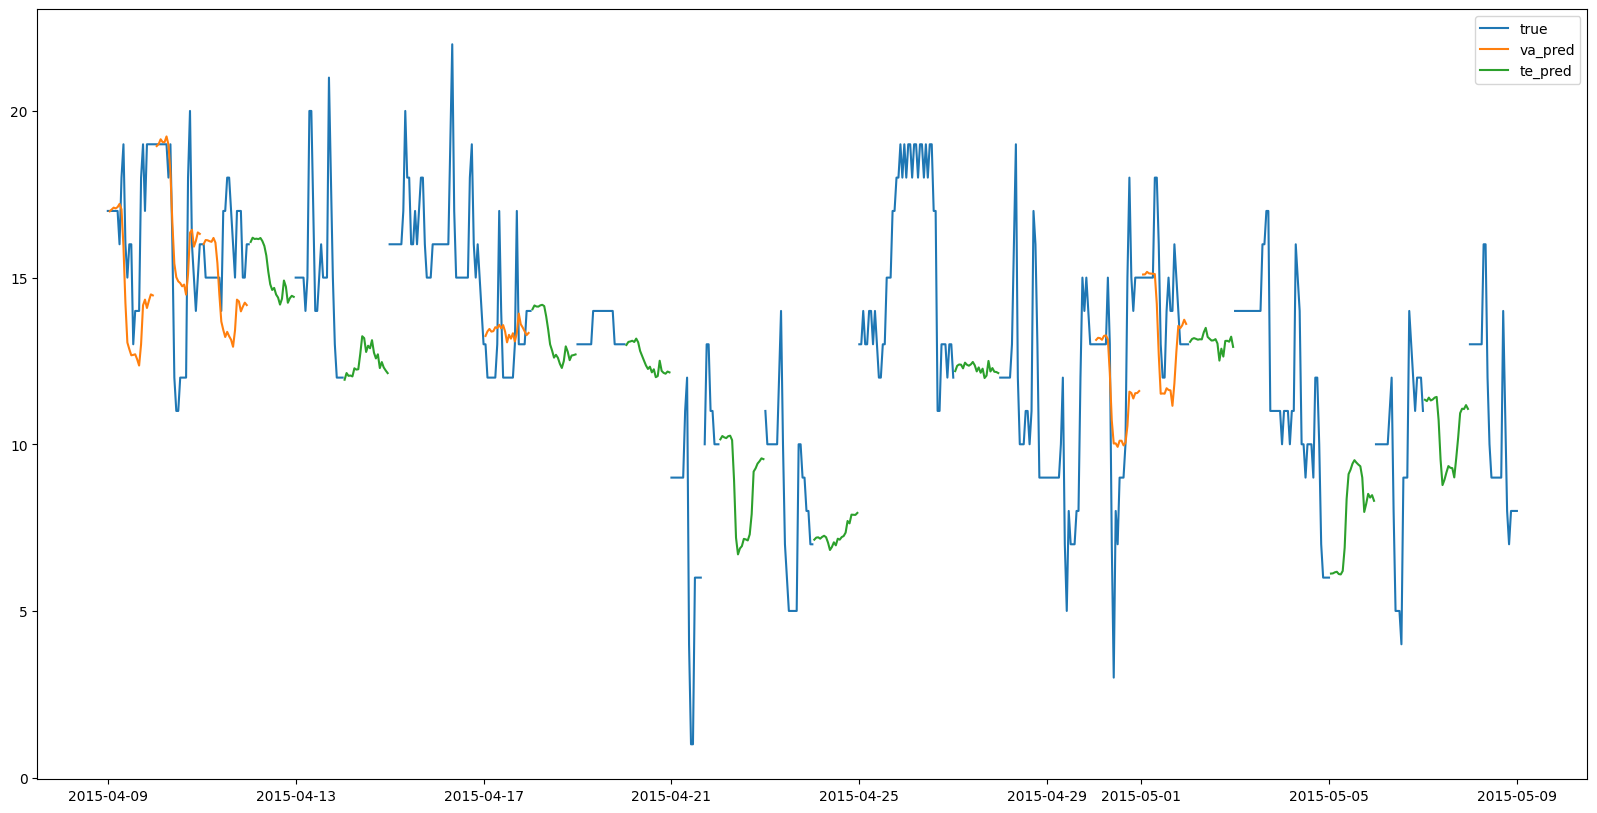

In [42]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTMのマルチステップ予測 学習率0.0001 epoch10


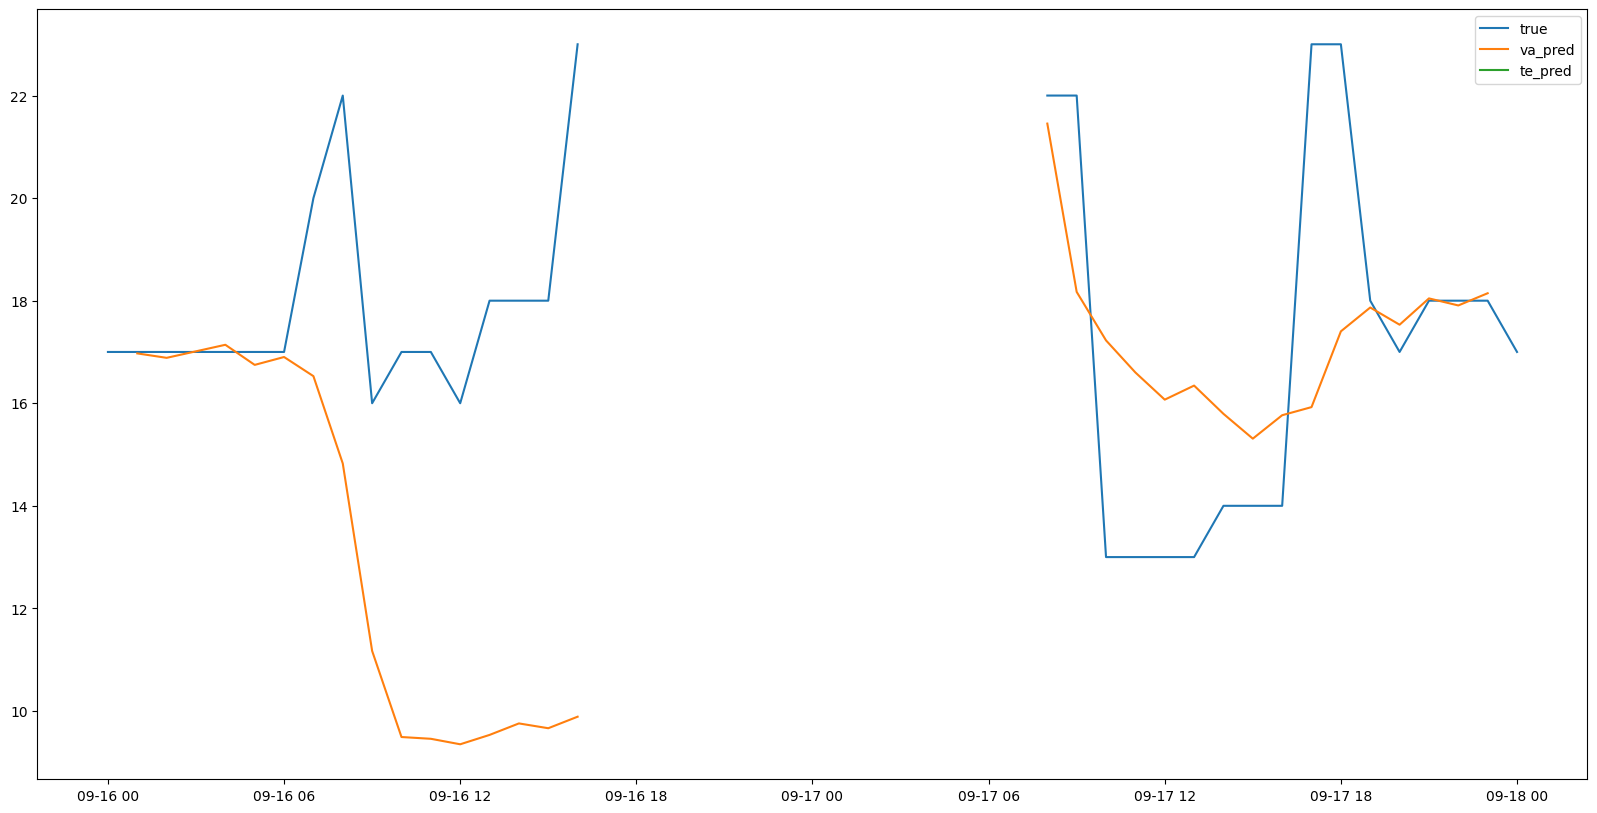

In [44]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [43]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22406, 24, 2)
2014-09-01 00:00:00 (24576, 24, 2)
2014-10-01 00:00:00 (25276, 24, 2)
2014-11-01 00:00:00 (26046, 24, 2)
2014-12-01 00:00:00 (26746, 24, 2)
2015-01-01 00:00:00 (27516, 24, 2)
2015-02-01 00:00:00 (28286, 24, 2)
2015-03-01 00:00:00 (28846, 24, 2)
2015-04-01 00:00:00 (29616, 24, 2)
2015-05-01 00:00:00 (30316, 24, 2)
2015-06-01 00:00:00 (31086, 24, 2)
2015-07-01 00:00:00 (31786, 24, 2)
2015-08-01 00:00:00 (32556, 24, 2)


# Submissionの作成

In [157]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [158]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [159]:
df_submit[df_submit["predict"] == 1][["id", "bikes_available"]]

,id,bikes_available
8761,8761,15.073997
8762,8762,15.041523
8763,8763,15.065933
8764,8764,15.097093
8765,8765,15.107909
...,...,...
1226347,1226347,11.030661
1226348,1226348,10.902891
1226349,1226349,10.866402
1226350,1226350,10.792340


In [160]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])

In [161]:
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]

In [162]:
df_submit.isnull().sum()

id                 0
bikes_available    0
dtype: int64

In [164]:
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)

In [165]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,15.073998
1,8762,15.041523
2,8763,15.065933
3,8764,15.097093
4,8765,15.107909
...,...,...
193195,1226347,11.030661
193196,1226348,10.902891
193197,1226349,10.866402
193198,1226350,10.792340
